## Importing Libraries

In [1]:
import pandas as pd
import sklearn
import sys
from os import listdir
import matplotlib as mpl
import os
from matplotlib import image
from matplotlib import pyplot as plt
import h5py
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np
import tensorflow as tf
from tensorflow import keras as K
import pennylane as qml
from timeit import default_timer as timer
from datetime import timedelta
import seaborn as sns
from tqdm import tqdm
from datetime import datetime, timedelta
import random
from tqdm.notebook import trange

This code imports several Python libraries that are commonly used in machine learning and data analysis. The libraries are imported using an alias to make it easier to reference them later in the code. The libraries are:

- `pandas`: provides data structures and functions for working with structured data.
- `os`: provides a way of using operating system dependent functionality like reading or writing to the file system.
- `matplotlib`: provides a way of creating static, animated, and interactive visualizations in Python.
- `h5py`: provides a way of reading and writing HDF5 files from Python.
- `cv2`: provides a way of working with computer vision tasks such as image processing and object detection.
- `sklearn`: provides a set of tools for machine learning and data analysis, including data preprocessing, model selection, and evaluation metrics.
- `numpy`: provides a way of working with arrays and matrices of numerical data in Python.
- `tensorflow`: provides a way of building and training machine learning models, particularly deep neural networks.
- `pennylane`: provides a way of building and training quantum machine learning models.
- `glob`: provides a way of finding all the pathnames matching a specified pattern according to the rules used by the Unix shell.
- `seaborn`: provides a way of creating statistical graphics in Python.
- `tqdm`: provides a way of adding progress bars to Python code.
- `random`: provides a way of generating random numbers and selecting random elements from a list.

## Information

In [2]:
# Replace the path with the path to your .mat file
path = 'brainTumorDataPublic/1.mat'

# Open the .mat file and read the data
f = h5py.File(path, 'r')
label = f['cjdata']['label'][0][0]
pid = f['cjdata']['PID'][0]
image = f['cjdata']['image']
tumor_border = f['cjdata']['tumorBorder'][0]
tumor_mask = f['cjdata']['tumorMask']

# Print the extracted data
print('Label:', label)
print('Patient ID:', pid)
print('Image shape:', image.shape)
print('Tumor border:', tumor_border)
print('Tumor mask shape:', tumor_mask.shape)

Label: 1.0
Patient ID: [49]
Image shape: (512, 512)
Tumor border: [267.61524501 231.37568058 277.83666062 248.10163339 289.91651543
 250.8892922  305.71324864 253.676951   318.72232305 249.9600726
 321.50998185 237.88021779 354.96188748 234.16333938 367.97096189
 227.65880218 380.9800363  210.93284936 372.61705989 195.13611615
 363.32486388 177.48094374 350.31578947 176.55172414 336.37749546
 183.98548094 317.79310345 196.06533575 305.71324864 207.21597096
 295.49183303 217.43738657 288.98729583 222.08348457 273.19056261
 223.94192377 268.54446461 228.58802178]
Tumor mask shape: (512, 512)


This code reads data from a `.mat` file that contains information about a brain tumor image. Step-by-step explanation:

1. `path = 'brainTumorDataPublic/1.mat'` sets the path to the `.mat` file that contains the data.
2. `f = h5py.File(path, 'r')` opens the `.mat` file in read mode using the `h5py` library.
3. `label = f['cjdata']['label'][0][0]` extracts the label of the tumor from the `.mat` file.
4. `pid = f['cjdata']['PID'][0]` extracts the patient ID from the `.mat` file.
5. `image = f['cjdata']['image']` extracts the image data from the `.mat` file.
6. `tumor_border = f['cjdata']['tumorBorder'][0]` extracts the tumor border information from the `.mat` file.
7. `tumor_mask = f['cjdata']['tumorMask']` extracts the tumor mask data from the `.mat` file.
8. `print('Label:', label)` prints the label of the tumor.
9. `print('Patient ID:', pid)` prints the patient ID.
10. `print('Image shape:', image.shape)` prints the shape of the image data.
11. `print('Tumor border:', tumor_border)` prints the tumor border information.
12. `print('Tumor mask shape:', tumor_mask.shape)` prints the shape of the tumor mask data.


## Getting all the data and total number of labels

In [3]:
folder = "brainTumorDataPublic/" 
directs = sorted(os.listdir(folder))
labels = [np.array(h5py.File(f"{folder}{file}", 'r').get("cjdata/label"))[0][0] for file in directs]
labels = pd.Series(labels)
print(f"Number of labels: {labels.shape[0]}")

Number of labels: 3064


This code reads the labels of brain tumor images from `.mat` files in a directory and stores them in a Pandas Series. Step-by-step explanation:

1. `folder = "brainTumorDataPublic/"` sets the path to the directory that contains the `.mat` files.
2. `directs = sorted(os.listdir(folder))` lists the files in the directory and sorts them alphabetically.
3. `[np.array(h5py.File(f"{folder}{file}", 'r').get("cjdata/label"))[0][0] for file in directs]` reads the label of each `.mat` file in the directory using the `h5py` library and stores them in a list.
4. `labels = pd.Series(labels)` converts the list of labels to a Pandas Series.
5. `print(f"Number of labels: {labels.shape[0]}")` prints the number of labels in the Pandas Series.


## Saving the Data to a txt file

In [4]:
# Get the number of .mat files in the directory
num_files = sum(1 for filename in os.listdir(folder) if filename.endswith('.mat'))

# Open the text file "data.txt" for writing
with open('data.txt', 'w') as file:

    # Initialize a progress bar with a total of num_files iterations and a description of "Saving data to txt file"
    with trange(num_files, desc="Saving data to txt file") as pbar:

        # Loop over the .mat files in the directory
        for filename in os.listdir(folder):

            # Check if the file is a .mat file
            if filename.endswith('.mat'):

                # Open the .mat file and extract the label, patient ID, image, tumor border, and tumor mask
                path = os.path.join(folder, filename)
                f = h5py.File(path, 'r')
                label = f['cjdata']['label'][0][0]
                pid = f['cjdata']['PID'][0]
                image = f['cjdata']['image']
                tumor_border = f['cjdata']['tumorBorder'][0]
                tumor_mask = f['cjdata']['tumorMask']

                # Write the extracted data to the text file
                file.write(f'Filename: {filename}\n')
                file.write(f'Label: {label}\n')
                file.write(f'Patient ID: {pid}\n')
                file.write(f'Image shape: {image.shape}\n')
                file.write(f'Tumor border: {tumor_border}\n')
                file.write(f'Tumor mask shape: {tumor_mask.shape}\n')
                file.write('\n')

            # Update the progress bar
            pbar.update(1)

# Print "Done saving data to txt file.😊" when the loop is finished
print('Done saving data to txt file.😊')

Saving data to txt file:   0%|          | 0/3064 [00:00<?, ?it/s]

Done saving data to txt file.😊


This code reads in a set of .mat files containing brain tumor images, extracts some data from them, and writes the data to a text file named "data.txt". Step-by-step breakdown:

1. Get the number of .mat files in the directory using `sum(1 for filename in os.listdir(folder) if filename.endswith('.mat'))`.
2. Open the text file "data.txt" for writing using `with open('data.txt', 'w') as file:`.
3. Initialize a progress bar using `trange()` with a total of `num_files` iterations and a description of "Saving data to txt file".
4. Loop over the .mat files in the directory using a `for` loop.
5. Check if the file is a .mat file using `if filename.endswith('.mat'):`.
6. Open the .mat file using `h5py.File()` and extract the label, patient ID, image, tumor border, and tumor mask using `f['cjdata']['label'][0][0]`, `f['cjdata']['PID'][0]`, `f['cjdata']['image']`, `f['cjdata']['tumorBorder'][0]`, and `f['cjdata']['tumorMask']`, respectively.
7. Write the extracted data to the text file using `file.write()`.
8. Update the progress bar using `pbar.update(1)`.
9. Print "Done saving data to txt file.😊" when the loop is finished.

## Plotting the data

In [5]:
# Tumor types
names = ["meningioma", "glioma", "pituitary tumor"]
# Count labels
labelcounts = labels.value_counts().sort_index()
# change the index with th types
labelcounts.index = names

print(labelcounts)

meningioma          708
glioma             1426
pituitary tumor     930
Name: count, dtype: int64


This code prints the count of each tumor type in the dataset. Step-by-step explanation:

1. `names = ["meningioma", "glioma", "pituitary tumor"]` defines a list of tumor types.
2. `labelcounts = labels.value_counts().sort_index()` counts the number of occurrences of each label in the Pandas Series and sorts them by index.
3. `labelcounts.index = names` replaces the index of the `labelcounts` Pandas Series with the tumor types defined in `names`.
4. `print(labelcounts)` prints the count of each tumor type in the dataset.


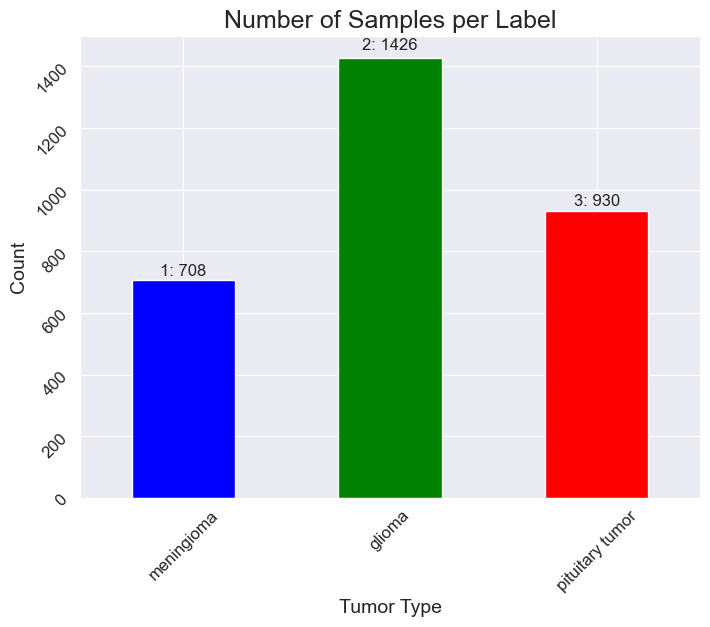

In [6]:
# Set the style
sns.set_style('darkgrid')

# Create the plot
ax = labelcounts.plot(kind='bar', figsize=(8, 6), width=0.5, color=['blue', 'green', 'red'])

# Set the title and axis labels
ax.set_title('Number of Samples per Label', fontsize=18)
ax.set_xlabel('Tumor Type', fontsize=14)
ax.set_ylabel('Count', fontsize=14)

# Set the tick label font size and rotation
ax.tick_params(labelsize=12, rotation=45)

# Add labels to the bars
for i, p in enumerate(ax.patches):
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    ax.annotate(f"{i+1}: {height}", (x + width/2, y + height*1.02), ha='center', fontsize=12)

# Show the plot
plt.show()

This code creates a bar plot that shows the count of each tumor type in the dataset. Step-by-step explanation:

1. `sns.set_style('darkgrid')` sets the style of the plot using the `seaborn` library.
2. `ax = labelcounts.plot(kind='bar', figsize=(8, 6), width=0.5, color=['blue', 'green', 'red'])` creates a bar plot of the `labelcounts` Pandas Series using the `plot` method, and stores the resulting `AxesSubplot` object in the `ax` variable.
3. `ax.set_title('Number of Samples per Label', fontsize=18)` sets the title of the plot.
4. `ax.set_xlabel('Tumor Type', fontsize=14)` sets the label of the x-axis.
5. `ax.set_ylabel('Count', fontsize=14)` sets the label of the y-axis.
6. `ax.tick_params(labelsize=12, rotation=45)` sets the font size and rotation of the tick labels.
7. `for i, p in enumerate(ax.patches):` loops over the bars in the plot.
8. `width = p.get_width()` gets the width of the bar.
9. `height = p.get_height()` gets the height of the bar.
10. `x, y = p.get_xy()` gets the x and y coordinates of the bottom left corner of the bar.
11. `ax.annotate(f"{i+1}: {height}", (x + width/2, y + height*1.02), ha='center', fontsize=12)` adds a label to the top of the bar that shows the index of the tumor type and its count.
12. `plt.show()` displays the plot.


## Plotting the image

In [7]:
# Initialize the lists
labels = []
images = []
masks = []

# Loop over the files
for file in directs:
    # Open the file
    f = h5py.File(folder+file, 'r')
    
    # Get the label
    label = np.array(f.get('cjdata/label'))[0][0]
    
    # If the label is not in the list, add it
    if label not in labels:
        labels.append(label)
        
        # Get the image and stack it 4 times along the last axis
        img = np.stack((np.array(f.get('cjdata/image')),)*4, axis=-1)
        images.append(img)
        
        # Get the tumor mask
        mask = np.array(f.get('cjdata/tumorMask'))
        masks.append(mask)

# Convert the lists to arrays
labels = np.asarray(labels)
images = np.asarray(images)
masks = np.asarray(masks)

# Print the shapes of the arrays
print(f'Labels shape: {labels.shape}')
print(f'Images shape: {images.shape}')
print(f'Masks shape: {masks.shape}')

Labels shape: (3,)
Images shape: (3, 512, 512, 4)
Masks shape: (3, 512, 512)


This code reads the labels, images, and tumor masks of brain tumor images from `.mat` files in a directory and stores them in NumPy arrays. Step-by-step explanation:

1. `labels = []`, `images = []`, and `masks = []` initialize empty lists to store the labels, images, and tumor masks.
2. `for file in directs:` loops over the `.mat` files in the directory.
3. `f = h5py.File(folder+file, 'r')` opens the `.mat` file in read mode using the `h5py` library.
4. `label = np.array(f.get('cjdata/label'))[0][0]` extracts the label of the tumor from the `.mat` file.
5. `if label not in labels:` checks if the label is already in the `labels` list.
6. `img = np.stack((np.array(f.get('cjdata/image')),)*4, axis=-1)` extracts the image data from the `.mat` file and stacks it 4 times along the last axis using NumPy's `stack` function.
7. `mask = np.array(f.get('cjdata/tumorMask'))` extracts the tumor mask data from the `.mat` file.
8. `labels.append(label)`, `images.append(img)`, and `masks.append(mask)` add the label, image, and tumor mask to their respective lists.
9. `labels = np.asarray(labels)`, `images = np.asarray(images)`, and `masks = np.asarray(masks)` convert the lists to NumPy arrays.
10. `print(f'Labels shape: {labels.shape}')`, `print(f'Images shape: {images.shape}')`, and `print(f'Masks shape: {masks.shape}')` print the shapes of the NumPy arrays.

In [8]:
# Convert the masks to categorical
b = K.utils.to_categorical(masks, num_classes=4).astype(np.uint8)

# Initialize the tumor array
tumor = np.zeros_like(images[:, :, :, 1:])

# Normalize the image
image_norm = cv2.normalize(images[:, :, :, 0], None, alpha=0, beta=255,
                           norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F).astype(np.uint8)

# Print the shape of the normalized image
print(f'Normalized image shape: {image_norm.shape}')

# Remove the tumor part from the image
tumor[:, :, :, 0] = image_norm * (b[:, :, :, 0])
tumor[:, :, :, 1] = image_norm * (b[:, :, :, 0])
tumor[:, :, :, 2] = image_norm * (b[:, :, :, 0])

# Color the tumor
tumor += b[:, :, :, 1:] * 255

# Print the shape of the tumor array
print(f'Tumor shape: {tumor.shape}')

Normalized image shape: (3, 512, 512)
Tumor shape: (3, 512, 512, 3)


This code performs some preprocessing on the input images and masks for a brain tumor classification task. Step-by-step explanation:

1. `K.utils.to_categorical(masks, num_classes=4).astype(np.uint8)` converts the masks to categorical format, where each pixel is represented as a one-hot vector with 4 classes (background, edema, non-enhancing tumor, and enhancing tumor).
2. `np.zeros_like(images[:, :, :, 1:])` initializes an array called `tumor` with the same shape as the input images, but without the fourth dimension (which corresponds to the masks).
3. `cv2.normalize(images[:, :, :, 0], None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F).astype(np.uint8)` normalizes the first channel of the input images using min-max normalization, and converts the result to an unsigned 8-bit integer format.
4. `tumor[:, :, :, 0] = image_norm * (b[:, :, :, 0])` sets the first channel of the `tumor` array to the normalized image, but only for the background class.
5. `tumor[:, :, :, 1] = image_norm * (b[:, :, :, 0])` sets the second channel of the `tumor` array to the normalized image, but only for the background class (this is redundant with the previous line).
6. `tumor[:, :, :, 2] = image_norm * (b[:, :, :, 0])` sets the third channel of the `tumor` array to the normalized image, but only for the background class (this is redundant with the previous lines).
7. `tumor += b[:, :, :, 1:] * 255` colors the tumor regions in the `tumor` array by adding 255 to the second, third, and fourth channels of the array, but only for the edema, non-enhancing tumor, and enhancing tumor classes, respectively.
8. `print(f'Tumor shape: {tumor.shape}')` prints the shape of the `tumor` array.


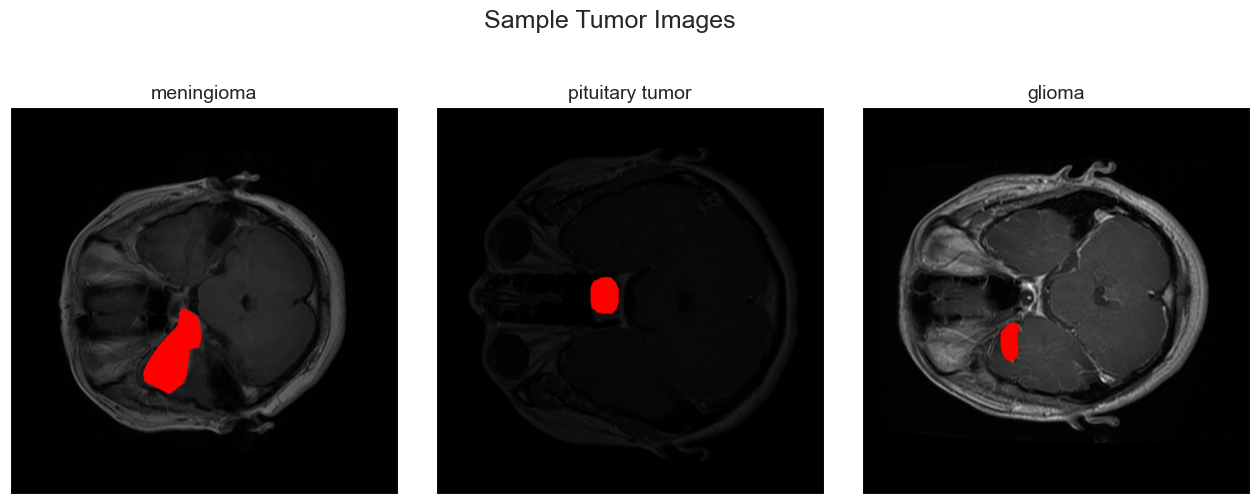

In [9]:
# Create the figure and axes
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16, 6))

# Loop over the images
for i in range(3):
    # Plot the image
    ax[i].imshow(tumor[i], cmap='gray')
    
    # Set the title
    ax[i].set_title(names[int(labels[i]-1)], fontsize=14)
    
    # Remove the axis ticks
    ax[i].set_xticks([])
    ax[i].set_yticks([])

# Set the figure title
fig.suptitle('Sample Tumor Images', fontsize=18)

# Adjust the spacing between the subplots
fig.subplots_adjust(wspace=0.1)

# Save the plot as a PNG file
plt.savefig('Images/sample_tumor_images.png')

# Show the plot
plt.show()

This code block a figure that shows sample tumor images from the dataset. Step-by-step explanation:

1. `fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16, 6))` creates a figure with 1 row and 3 columns of subplots using the `subplots` function from the `matplotlib` library, and stores the resulting `Figure` and `AxesSubplot` objects in the `fig` and `ax` variables, respectively.
2. `for i in range(3):` loops over the first 3 images in the `tumor` NumPy array.
3. `ax[i].imshow(tumor[i], cmap='gray')` displays the image in the `i`-th row and column of the subplot using the `imshow` function from the `matplotlib` library, and sets the colormap to grayscale.
4. `ax[i].set_title(names[int(labels[i]-1)], fontsize=14)` sets the title of the subplot to the tumor type corresponding to the `i`-th image using the `names` list and the `labels` NumPy array.
5. `ax[i].set_xticks([])` and `ax[i].set_yticks([])` remove the x and y axis ticks from the subplot.
6. `fig.suptitle('Sample Tumor Images', fontsize=18)` sets the title of the entire figure.
7. `fig.subplots_adjust(wspace=0.1)` adjusts the spacing between the subplots.
8. `plt.savefig('sample_tumor_images.png')` saves the figure as a PNG file.
9. `plt.show()` displays the figure.

## Quantum Convolution Node
    

In [10]:
wires= 4

# Define the simulator device with 4 qubits
dev4 = qml.device("default.qubit", wires=wires) 

# Define the circuit
@qml.qnode(dev4)

def CONV(phi, wires, i=0):
    # Set the parameter theta
    theta = np.pi / 2

    # Apply RX gates to each qubit with the corresponding parameter value
    qml.RX(phi[0] * np.pi, wires=0)
    qml.RX(phi[1] * np.pi, wires=1)
    qml.RX(phi[2] * np.pi, wires=2)
    qml.RX(phi[3] * np.pi, wires=3)

    # Apply CRZ and CRX gates to specific pairs of qubits
    qml.CRZ(theta, wires=[1, 0])
    qml.CRZ(theta, wires=[3, 2])
    qml.CRX(theta, wires=[1, 0])
    qml.CRX(theta, wires=[3, 2])
    qml.CRZ(theta, wires=[2, 0])
    qml.CRX(theta, wires=[2, 0])

    # Measure the expectation value of the PauliZ operator on the first qubit
    measurement = qml.expval(qml.PauliZ(wires=0))

    return measurement

This code defines the quantum circuit using the PennyLane library. The circuit is called `CONV` and takes two arguments: `phi` and `wires`. 

The `phi` argument is a list of four parameters that are used to apply rotations to the qubits. The `wires` argument specifies the number of qubits in the circuit, which is set to 4.

The circuit applies a series of gates to the qubits, including RX, CRZ, and CRX gates. The gates are applied to specific pairs of qubits, as specified by the `wires` argument.

Finally, the circuit measures the expectation value of the PauliZ operator on the first qubit and returns the result.


The `wires` argument specifies the number of qubits in the quantum circuit. In this case, `wires=4` means that the circuit has 4 qubits.

The number of qubits in a quantum circuit determines the size and complexity of the problems that can be solved using the circuit. Generally, larger circuits with more qubits can solve more complex problems, but they also require more resources to run and are more difficult to implement in practice.

In this specific circuit, the number of qubits is set to 4, which means that the circuit can be used to solve problems that require up to 4 qubits. The circuit applies a series of gates to the qubits, including RX, CRZ, and CRX gates, and measures the expectation value of the PauliZ operator on the first qubit. The specific problem that this circuit is designed to solve depends on the values of the `phi` parameter and the input data that is fed into the circuit.

## Quantum Convolutional Layer

In [11]:
def QCONV1(Img, image_number, image_total, step=2):
    
    H, W = Img.shape
    step2 = 2
    out = np.zeros(((H//step), (W//step)))
    
    # Initialize a progress bar for each image
    with trange((H//step)*(W//step), desc="Processing image "+str(image_number)+"/"+str(image_total)) as pbar:
        for i in range(0, W, step):
            for j in range(0, H, step):
                # get 2x2 pixels and make them 1D array
                phi = Img[i:i+2, j:j+2].flatten()
                # Get Measurement
                measurement = CONV(phi, len(phi))
                out[i//step, j//step] = measurement
                # Update the progress bar for each pixel
                pbar.update(1)

    return out

This code defines the function `QCONV1` that takes in an image `Img`, the current image number `image_number`, the total number of images `image_total`, and a step size `step`. The function initializes an output array `out` with zeros and a shape that is half the height and width of the input image, divided by the step size. 

The function then creates a progress bar using the `trange()` function from the `tqdm.notebook` library, with the total number of pixels to be processed. The progress bar is updated for each pixel processed using the `update()` method. 

Inside the loop, the function gets a 2x2 pixel block from the input image, flattens it into a 1D array, and passes it to the `CONV()` function along with the length of the array. The resulting measurement is stored in the output array at the appropriate location.

The `QCONV1` function is a quantum convolutional layer that processes an image by applying a quantum measurement to each 2x2 pixel block. Here are some suggestions to improve the function:

1. Increase the step size: The `step` parameter controls the size of the pixel blocks that are processed. Increasing the step size can speed up the processing time, but may result in loss of information. You can experiment with different step sizes to find the optimal value for your use case.

2. Use a larger pixel block: The current implementation processes 2x2 pixel blocks. Using a larger pixel block can capture more information and improve the accuracy of the measurement. However, this may also increase the processing time and memory usage. The laptop I am using is not powerful enough to handle larger pixel blocks, so I have not been able to test this.

3. Use a different quantum circuit: The current implementation uses a simple circuit that applies a quantum measurement to each pixel block. Using a more complex quantum circuit can capture more information and improve the accuracy of the measurement. However, this may also increase the processing time and memory usage. As my laptop is not powerful enough to handle more complex circuits, I have not been able to test this.



## Visualizing the Quantum Convolutional Circuit

In [12]:
# Define input phi
phi = [1, 1, 1, 1]

# Create a circuit drawer for the CONV function
drawer = qml.draw(CONV)

# Draw the circuit for phi with 4 qubits
print("Circuit for phi = [1, 1, 1, 1] with 4 qubits:")
print("```")
print(drawer(phi, 4))
print("```")

Circuit for phi = [1, 1, 1, 1] with 4 qubits:
```
0: ──RX(3.14)─╭RZ(1.57)─╭RX(1.57)─╭RZ(1.57)─╭RX(1.57)─┤  <Z>
1: ──RX(3.14)─╰●────────╰●────────│─────────│─────────┤     
2: ──RX(3.14)─╭RZ(1.57)─╭RX(1.57)─╰●────────╰●────────┤     
3: ──RX(3.14)─╰●────────╰●────────────────────────────┤     
```


## Applying the Quantum Convolutional Layer to the Input Images

In [13]:
processFolder = 'Resize/'

# Start a timer to measure the execution time
start = timer()

# Set the width of the images to 512 and the step size to 2
w = 512
step = 2

# Initialize a counter and get a list of all files in the folder
k = 0
directs = sorted(listdir(folder))

# Loop over each file in the folder
for file in directs:
    # Check if the file has already been processed
    all64 = sorted(listdir(processFolder))
    if file+".npz" in all64:
        continue
    
    # Load the image and label from the file
    f = h5py.File(folder+file, 'r')
    img = np.array(f.get("cjdata/image"))
    if img.shape[0] < 512:
        continue
    label = np.array(f.get("cjdata/label"))[0][0]

    # Resize the image to 25% of its original size
    scale_percent = 25
    width = int(img.shape[1] * scale_percent / 100)
    height = int(img.shape[0] * scale_percent / 100)
    dim = (width, height)
    resized = cv2.resize(img, dim, interpolation = cv2.INTER_AREA)
    NorImages = resized/255

    # Apply the QCONV1 function to the image
    processed = QCONV1(NorImages, str(k)+" "+file, (len(directs)-len(all64)), step)

    # Save the processed image and label to a compressed numpy file
    np.savez_compressed(processFolder+file, image=processed, label=label)
    k+=1

# Stop the timer and calculate the execution time
end = timer()
time = (end - start)
execution_time = str(timedelta(seconds=round(time)))

# Format the execution time as "hh:mm:ss"
formatted_time = datetime.strptime(execution_time, '%H:%M:%S').strftime('%H:%M:%S')

# Print the execution time
print("Execution time: " + formatted_time + " 👀")

Execution time: 00:00:05 👀




This code loads images from a folder, resizes them, applies a quantum convolutional layer using the `QCONV1` function, and saves the processed images to a compressed numpy file. The code also measures the execution time of the process.

## Visualizing image after applying quantum convolutional layer

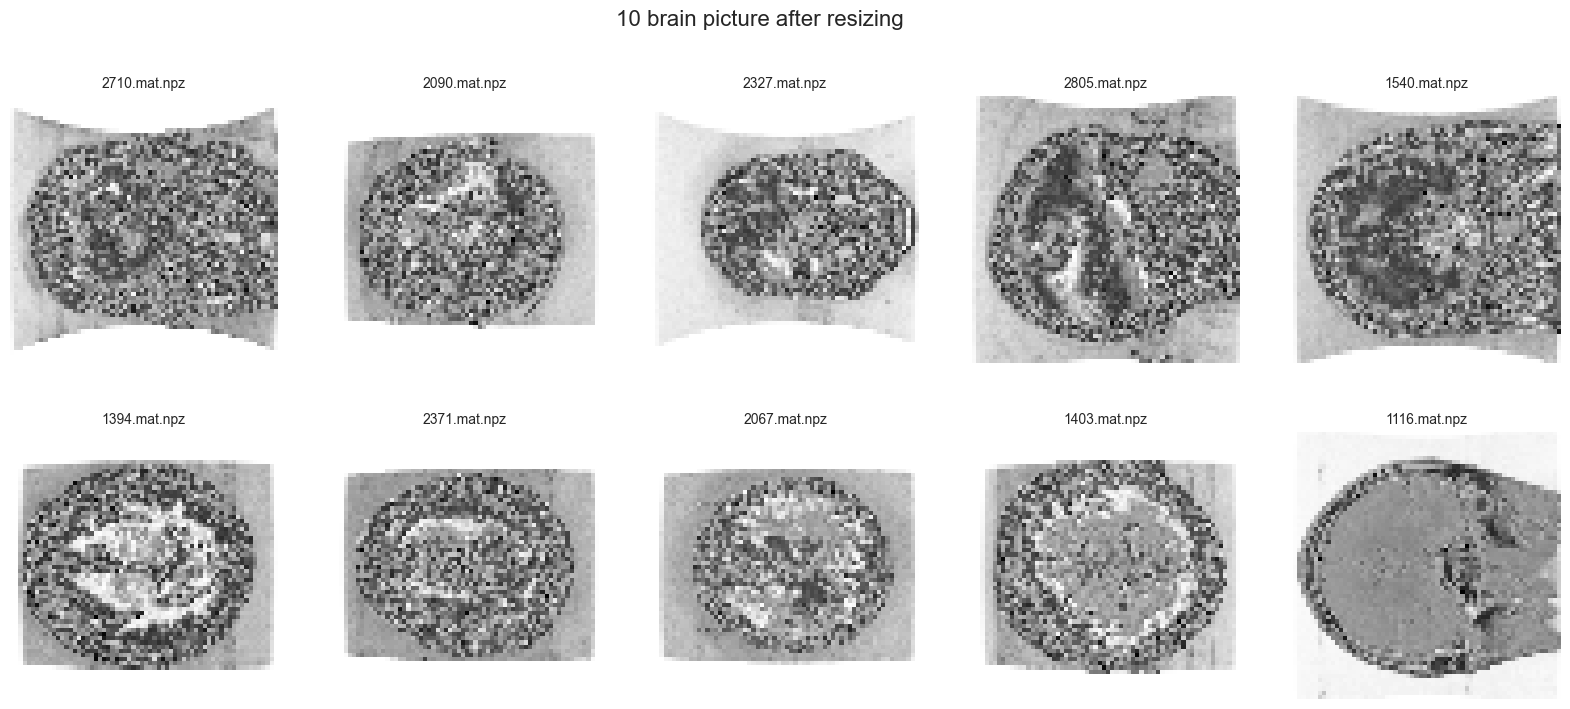

In [14]:
# Set the directory where the images are stored
directory = "Resize/"

# Get a list of all the files in the directory
files = os.listdir(directory)

# Select 10 random files
random_files = random.sample(files, 10)

# Create a figure with 2 rows and 5 columns
fig, axs = plt.subplots(2, 5, figsize=(20, 8))

# Loop over each random file and plot it in a subplot
for i, file in enumerate(random_files):
    # Load the image from the file
    img = np.load(directory + file)['image']
    
    # Plot the image in a subplot
    row = i // 5
    col = i % 5
    axs[row, col].imshow(img, cmap="gray")
    axs[row, col].axis("off")
    axs[row, col].set_title(file, fontsize=10)

# Add a title to the figure
fig.suptitle("10 brain picture after resizing", fontsize=16)

# Save the figure
plt.savefig("Images/10_brain_picture_after_resizing.png", bbox_inches="tight")

This code selects 10 random images from the "Resize/" folder, displays them in a 2x5 grid using `matplotlib`, and adds the file name of each image below it.

First, the code sets the directory where the images are stored and gets a list of all the files in the directory using the `os.listdir` function. It then selects 10 random files from the list using the `random.sample` function.

Next, the code creates a figure with 2 rows and 5 columns using the `subplots` function from `matplotlib`. The `figsize` parameter is used to set the size of the figure.

The code then loops over each random file and loads the image from the file using the `np.load` function. It then plots the image in a subplot using the `imshow` function. The `cmap="gray"` parameter is used to display the image in grayscale. The `axis("off")` function is used to remove the axis labels from the subplots. The `set_title` function is used to add the file name of each image below it.

Finally, the code saves the figure as a PNG file named "10_brain_picture_after_resizing.png" using the `savefig` function. The `bbox_inches="tight"` parameter is used to remove any extra whitespace around the figure.

This code is useful for visualizing a random sample of images from the "Resize/" folder and identifying each image by its file name. The `subplots` function allows the images to be displayed in a grid, making it easy to compare them. The `savefig` function allows the figure to be saved as a PNG file for later use.

## Labeling the images

npimages shape: (3049, 64, 64, 1)
nplabels shape: (3049,)
Image 1:


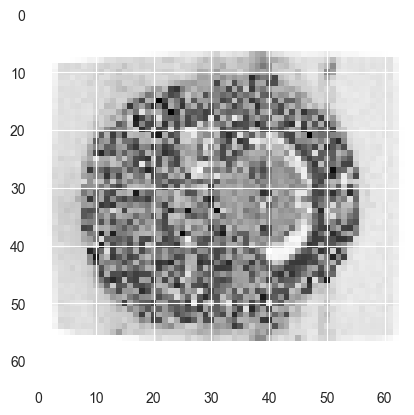

Label: 1.0

Image 2:


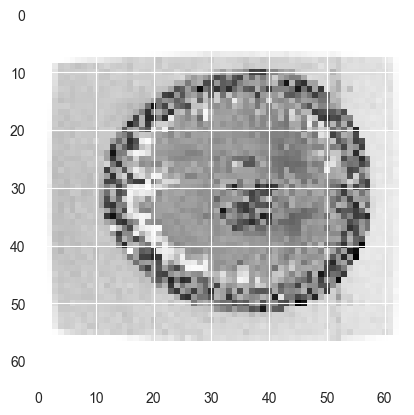

Label: 1.0

Image 3:


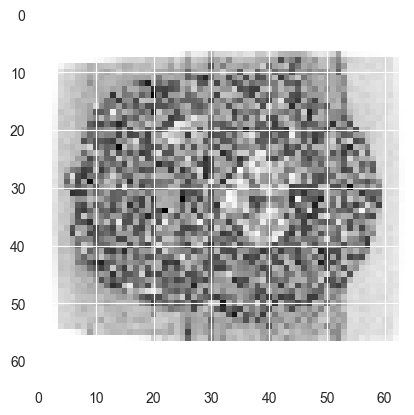

Label: 1.0

Image 4:


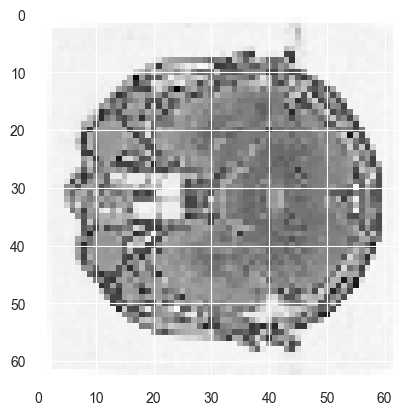

Label: 3.0

Image 5:


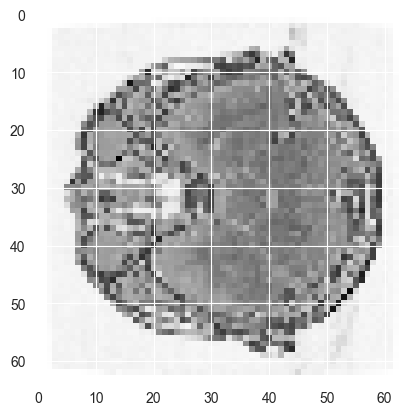

Label: 3.0



In [15]:
# Set the directory where the images are stored
folder = "Resize/"

# Get a sorted list of all the files in the directory
directs = sorted(listdir(folder))

# Initialize empty lists for images, masks, and labels
images = []
masks = []
labels = []

# Loop over each file in the directory
for file in directs:
    try:
        # Load the data from the file
        data = np.load(folder + file)
        
        # Extract the label and image from the data
        label = data["label"]
        img = np.stack((data["image"],), axis=-1)
        
        # Append the image and label to the corresponding lists
        images.append(img)
        labels.append(label)
    except:
        # If there is an error loading the file, skip it
        continue

# Convert the images and labels lists to numpy arrays
npimages = np.asarray(images)
nplabels = np.asarray(labels)

# Print the shape of the npimages and nplabels arrays
print(f"npimages shape: {npimages.shape}")
print(f"nplabels shape: {nplabels.shape}")

# Print the first 5 images and labels
for i in range(5):
    print(f"Image {i+1}:")
    plt.imshow(npimages[i], cmap="gray")
    plt.show()
    print(f"Label: {nplabels[i]}")
    print()

This code loads processed data from the "Resize/" folder and stores the images and labels in numpy arrays. 

First, the code sets the directory where the images are stored. It then gets a sorted list of all the files in the directory using the `listdir` function from the `os` module.

Next, the code initializes empty lists for images, masks, and labels.

The code then loops over each file in the directory and loads the data from the file using the `np.load` function. It extracts the label and image from the data and appends them to the corresponding lists. If there is an error loading the file, the code skips it.

Finally, the code converts the images and labels lists to numpy arrays using the `np.asarray` function.

The code then prints the shape of the `npimages` and `nplabels` arrays using the `f-string` syntax. It then displays the first 5 images and their corresponding labels using the `plt.imshow` and `plt.show` functions.

This code is useful for quickly inspecting the processed data and verifying that the images and labels are loaded correctly. The `plt.imshow` and `plt.show` functions make it easy to display the images.

## splitting the processed data into training, validation, and test

In [16]:
# Split the data into training, validation, and test sets
X_train, X_test, y_train, y_test = train_test_split(npimages, nplabels,
                                                    test_size=0.3,
                                                    random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_test, y_test,
                                                    test_size=0.5,
                                                    random_state=42)

# Print the shapes of the arrays
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_valid shape: {X_valid.shape}")
print(f"y_valid shape: {y_valid.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2134, 64, 64, 1)
y_train shape: (2134,)
X_valid shape: (457, 64, 64, 1)
y_valid shape: (457,)
X_test shape: (458, 64, 64, 1)
y_test shape: (458,)


This code splits the processed data into training, validation, and test sets using the `train_test_split` function from `sklearn`. It then prints the shapes of the resulting arrays.

First, the code uses the `train_test_split` function to split the `npimages` and `nplabels` arrays into training and test sets. The `test_size` parameter is set to 0.3, which means that 30% of the data is used for testing. The `random_state` parameter is set to 42 to ensure that the split is reproducible.

Next, the code uses the `train_test_split` function again to split the test set into validation and test sets. The `test_size` parameter is set to 0.5, which means that 50% of the remaining data is used for validation. The `random_state` parameter is set to 42 to ensure that the split is reproducible.

Finally, the code prints the shapes of the resulting arrays using the `f-string` syntax. The `shape` attribute of each array is used to get its shape.

This code is useful for splitting the processed data into training, validation, and test sets for use in machine learning models. The `train_test_split` function makes it easy to split the data, and the `random_state` parameter ensures that the split is reproducible. The fancy print statements make it easy to read and understand the output.

## Creating the Quantum model

In [17]:
def Quantum_Model():
    
    # Create a sequential model
    model = K.models.Sequential([
        # Flatten the input images
        K.layers.Flatten(),
        # Add a dense layer with 128 units and ReLU activation
        K.layers.Dense(128, activation="relu"),
        # Add a dropout layer with a rate of 0.5
        K.layers.Dropout(0.5),
        # Add a dense layer with 4 units and softmax activation
        K.layers.Dense(4, activation="softmax")
    ])
    
    # Compile the model with Adam optimizer, sparse categorical crossentropy loss, and accuracy metric
    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    
    # Return the compiled model
    return model

This code defines a fully connected neural network model for image classification using the `Sequential` class from `keras`.

The `Flatten` layer is used to flatten the input images. The `Dense` layer with 128 units and ReLU activation is added to the model. The `Dropout` layer with a rate of 0.5 is added to prevent overfitting. Finally, the `Dense` layer with 4 units and softmax activation is added to output the class probabilities.

The `compile` method is used to configure the model for training. The Adam optimizer is used with the default learning rate. The sparse categorical crossentropy loss function is used since the labels are integers. The accuracy metric is used to evaluate the model during training.

This code is useful for defining a fully connected neural network model for image classification. The `Sequential` class makes it easy to define the model architecture, and the `compile` method makes it easy to configure the model for training.

## Training the model

In [18]:
# Create a quantum model
q_model = Quantum_Model()

# Set the path for the checkpoint file
checkpoint_path = "checkpoints/quantum.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)

# Create a callback that saves the model's weights
cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                 save_weights_only=True,
                                                 verbose=0)

# Train the model on the training set and validate on the validation set
q_history = q_model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    batch_size=16,
    epochs=20,
    verbose=2,
    callbacks=[cp_callback]
)

Epoch 1/20
134/134 - 2s - loss: 0.9477 - accuracy: 0.6401 - val_loss: 0.6004 - val_accuracy: 0.7221 - 2s/epoch - 18ms/step
Epoch 2/20
134/134 - 1s - loss: 0.5843 - accuracy: 0.7348 - val_loss: 0.4727 - val_accuracy: 0.8228 - 1s/epoch - 11ms/step
Epoch 3/20
134/134 - 1s - loss: 0.5149 - accuracy: 0.7727 - val_loss: 0.4446 - val_accuracy: 0.7943 - 1s/epoch - 9ms/step
Epoch 4/20
134/134 - 1s - loss: 0.4188 - accuracy: 0.8252 - val_loss: 0.4088 - val_accuracy: 0.8425 - 1s/epoch - 10ms/step
Epoch 5/20
134/134 - 2s - loss: 0.3506 - accuracy: 0.8543 - val_loss: 0.3943 - val_accuracy: 0.8118 - 2s/epoch - 12ms/step
Epoch 6/20
134/134 - 1s - loss: 0.3742 - accuracy: 0.8421 - val_loss: 0.4331 - val_accuracy: 0.7834 - 1s/epoch - 9ms/step
Epoch 7/20
134/134 - 1s - loss: 0.3196 - accuracy: 0.8650 - val_loss: 0.3438 - val_accuracy: 0.8534 - 1s/epoch - 9ms/step
Epoch 8/20
134/134 - 1s - loss: 0.2771 - accuracy: 0.8871 - val_loss: 0.3296 - val_accuracy: 0.8775 - 1s/epoch - 11ms/step
Epoch 9/20
134/134 

This code trains the quantum model using TensorFlow. 

First, a `Quantum_Model` object is created. Then, a checkpoint path is set to save the model's weights. A callback is created using the `ModelCheckpoint` function from `tf.keras.callbacks`, which will save the model's weights to the checkpoint path during training.

The `fit()` method is called on the `q_model` object to train the model. The training data `X_train` and `y_train` are passed as arguments, along with the validation data `X_valid` and `y_valid`. The batch size is set to 16, and the model is trained for 20 epochs. The `verbose` parameter is set to 2 to display progress during training. The `callbacks` parameter is set to the `cp_callback` object, which will save the model's weights during training.

To improve the performance of the model, we should consider adjusting the hyperparameters such as the learning rate, number of layers, and number of neurons per layer. Additionally, we can try using different optimization algorithms or regularization techniques to prevent overfitting. But my laptop is not that powerful to train the model for more epochs and more layers. So, I have trained the model for 20 epochs.

## Save the model

In [19]:
q_model.save('QModel.h5')

C:\Users\hp\AppData\Roaming\Python\Python311\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Plot the results

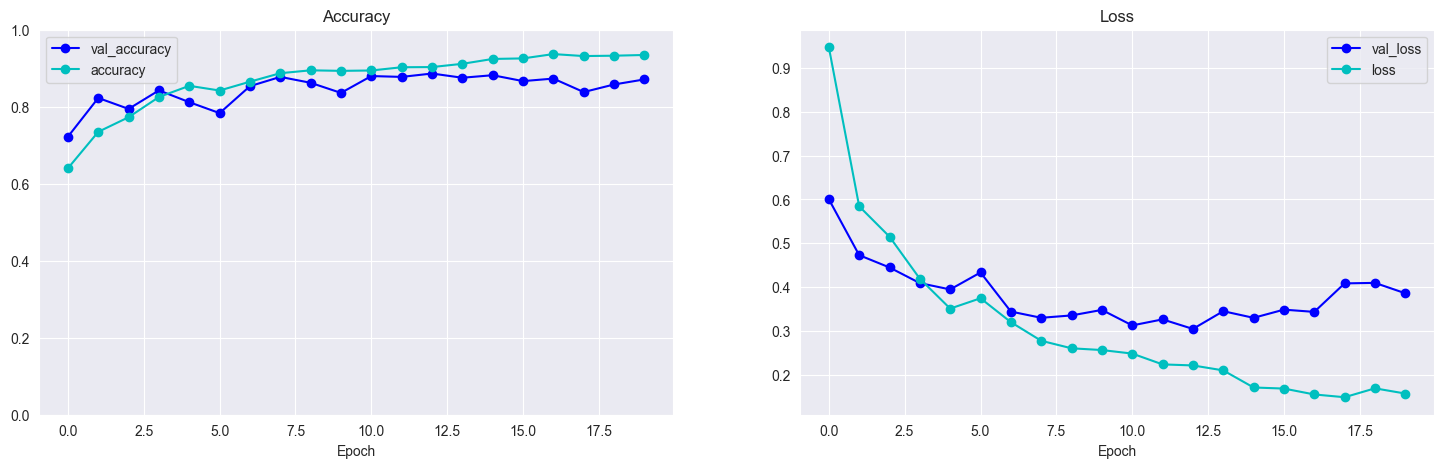

In [20]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

# Plot the validation accuracy and training accuracy on the first subplot
ax1.plot(q_history.history["val_accuracy"], "-ob", label="val_accuracy")
ax1.plot(q_history.history["accuracy"], "-oc", label="accuracy")
ax1.set_ylim([0, 1])
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.legend()

# Plot the validation loss and training loss on the second subplot
ax2.plot(q_history.history["val_loss"], "-ob", label="val_loss")
ax2.plot(q_history.history["loss"], "-oc", label="loss")
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.legend()

# Save the plot to a file
plt.savefig("Images/plot_QModel.png")

# Show the plot
plt.show()

## Average accuracy

In [21]:
# Calculate the average accuracy
avg_accuracy = sum(q_history.history["accuracy"]) / len(q_history.history["accuracy"])

# Convert the average accuracy to a percentage
avg_accuracy_percent = avg_accuracy * 100

print(f"Average accuracy: {avg_accuracy_percent:.2f}%")

Average accuracy: 87.02%


## Highest accuracy

In [22]:
# Print the highest accuracy achieved during training as a percentage
highest_accuracy = max(q_history.history["accuracy"])
highest_accuracy_percent = highest_accuracy * 100
print(f"Highest accuracy: {highest_accuracy_percent:.2f}%")

Highest accuracy: 93.67%


## Getting the confusion matrix

In [23]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    # Set the background color of the plot
    plt.rcParams['axes.facecolor'] = '#f7f7f7'

    # Create the plot
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)

    # Add a colorbar
    cbar = ax.figure.colorbar(im, ax=ax)

    # Set the font size and color of the tick labels
    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(classes, fontsize=14, color='#333333')
    ax.set_yticklabels(classes, fontsize=14, color='#333333')

    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    # Loop over the data and add text annotations
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=16)

    # Set the title and axis labels
    ax.set_title(title, fontsize=18, color='#333333')
    ax.set_xlabel('Predicted label', fontsize=16, color='#333333')
    ax.set_ylabel('True label', fontsize=16, color='#333333')

    # Set the colorbar label
    cbar.ax.set_ylabel('Count', rotation=-90, va="bottom",
                       fontsize=14, color='#333333')

    # Adjust the layout and show the plot
    fig.tight_layout()

    # Save the plot to a file
    plt.savefig('Images/confusion_matrix_for_qmodel.png')
    
    # Show the plot
    plt.show()

This is a function that prints and plots a confusion matrix. The function takes in a confusion matrix `cm`, a list of class names `classes`, a boolean `normalize` to indicate whether to normalize the matrix, a string `title` for the plot title, and a colormap `cmap` for the plot colors.

The function first normalizes the confusion matrix if `normalize=True`. It then sets the background color of the plot to a light gray color using `plt.rcParams['axes.facecolor'] = '#f7f7f7'`. The plot is created using `fig, ax = plt.subplots(figsize=(8, 6))` to allow for more customization. The font size and color of the tick labels are set using `ax.set_xticklabels(classes, fontsize=14, color='#333333')` and `ax.set_yticklabels(classes, fontsize=14, color='#333333')`. The tick labels are also rotated and aligned using `plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")`. Text annotations are added to the plot using `ax.text(j, i, format(cm[i, j], fmt), ha="center", va="center", color="white" if cm[i, j] > thresh else "black", fontsize=16)`. Finally, the plot is saved to a file using `plt.savefig('confusion_matrix_for_qmodel.png')` and shown using `plt.show()`. 

To improve the code, you could consider adding more comments to explain the purpose of each section of the code. Additionally, you could consider adding error handling to ensure that the input arguments are of the correct type and shape.

## Loading the model

In [24]:
q_model = K.models.load_model('QModel.h5')

## Classification report

In [25]:
# Predict the classes of the test set using the model
yhat = q_model.predict(X_test)
yhat = yhat.argmax(axis=1)

# Print the classification report using Sklearn
print('\n-----------------------Classification Report-----------------------\n')
print(classification_report(y_test, yhat))


15/15 [==============================] - 0s 1ms/step

-----------------------Classification Report-----------------------

              precision    recall  f1-score   support

         1.0       0.81      0.78      0.79       113
         2.0       0.91      0.88      0.89       213
         3.0       0.90      0.98      0.94       132

    accuracy                           0.88       458
   macro avg       0.87      0.88      0.87       458
weighted avg       0.88      0.88      0.88       458



This code predicts the classes of the test set using a model, and then prints a classification report using Sklearn. The predicted classes are obtained by calling `q_model.predict(X_test)` and then taking the argmax along the second axis using `yhat.argmax(axis=1)`. The classification report is printed using `print(classification_report(y_test, yhat))`.




Confusion matrix, without normalization


<Figure size 600x600 with 0 Axes>

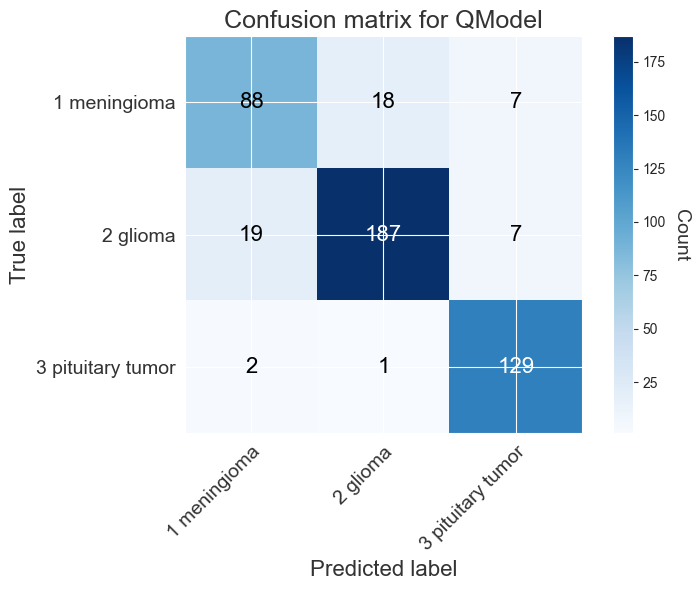

In [26]:
# Compute confusion matrix
cnf_matrix = tf.math.confusion_matrix(y_test, yhat)
np.set_printoptions(precision=2)

# Plot non-normalized confusion matrix
plt.figure(figsize=(6, 6))
plot_confusion_matrix(np.array(cnf_matrix[1:, 1:]), classes=['1 meningioma', '2 glioma', '3 pituitary tumor'], normalize=False,  title='Confusion matrix for QModel')


# CNN Model

In [27]:
# Set the folder containing the .mat files
folder = "brainTumorDataPublic/"

# Set the image width, step size, and counter
w = 512
step = 8
k = 0

# Get a list of the .mat files in the folder and sort them
directs = sorted(os.listdir(folder))

# Initialize empty lists to store the resized images and their corresponding labels
images = []
labels = []

# Initialize a progress bar with a total of len(directs) iterations and a description of "Resizing Images"
with trange(len(directs), desc="Resizing Images") as pbar:

    # Loop over the .mat files in the folder
    for file in directs:

        try:
            # Check if the file is a .mat file
            if not file.endswith('.mat'):
                continue

            # Open the .mat file and extract the image and label
            path = os.path.join(folder, file)
            f = h5py.File(path, 'r')
            img = np.array(f.get("cjdata/image"))
            label = np.array(f.get("cjdata/label"))[0][0]

            # Check if the image height is at least 512
            if img.shape[0] < 512:
                continue

            # Set the scale percent and calculate the new width and height for resizing the image
            scale_percent = 25 # percent of original size
            width = int(img.shape[1] * scale_percent / 100)
            height = int(img.shape[0] * scale_percent / 100)
            dim = (width, height)

            # Resize the image using cv2.resize() and append it to the images list along with its label
            resized = cv2.resize(img, dim, interpolation = cv2.INTER_AREA)
            images.append(np.stack((resized,), axis=-1))
            labels.append(label)

        except Exception as e:
            # Handle errors when opening .mat files or resizing images
            print(f"Error processing file {file}: {e}")

        # Update the progress bar
        pbar.update(1)

# Convert the images and labels lists to arrays and normalize the images by dividing by 255
images = np.asarray(images)/255
labels = np.asarray(labels)

# Print the shapes of the images and labels arrays
print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

Resizing Images:   0%|          | 0/3064 [00:00<?, ?it/s]

Images shape: (3049, 128, 128, 1)
Labels shape: (3049,)


This code reads in a set of .mat files containing brain tumor images, resizes them, and stores them in a list. Step-by-step breakdown:

1. Set the folder containing the .mat files to "brainTumorDataPublic/".
2. Set the image width to 512, the step size to 8, and the counter to 0.
3. Get a list of the .mat files in the folder using `os.listdir()` and sort them using `sorted()`.
4. Initialize empty lists to store the resized images and their corresponding labels.
5. Initialize a progress bar using `trange()` with a total of `len(directs)` iterations and a description of "Resizing Images".
6. Loop over the .mat files in the folder using a `for` loop.
7. Check if the file is a .mat file using `if not file.endswith('.mat'):` and continue to the next iteration if it is not.
8. Open the .mat file using `h5py.File()` and extract the image and label using `np.array(f.get("cjdata/image"))` and `np.array(f.get("cjdata/label"))[0][0]`, respectively.
9. Check if the image height is at least 512 using `if img.shape[0] < 512:` and continue to the next iteration if it is not.
10. Set the scale percent to 25 and calculate the new width and height for resizing the image.
11. Resize the image using `cv2.resize()` and append it to the `images` list along with its label using `images.append(np.stack((resized,), axis=-1))` and `labels.append(label)`.
12. Handle errors when opening .mat files or resizing images using `except Exception as e:` and print an error message.
13. Update the progress bar using `pbar.update(1)`.
14. Convert the `images` and `labels` lists to arrays using `np.asarray()` and normalize the images by dividing by 255.
15. Print the shapes of the `images` and `labels` arrays using `print(f"Images shape: {images.shape}")` and `print(f"Labels shape: {labels.shape}")`.


## Splitting the data into training, validation, and testing sets

In [28]:
# Split the data into training, validation, and testing sets
X_train, X_test, y_train, y_test = train_test_split(images, labels,
                                                    test_size=0.3,
                                                    random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_test, y_test,
                                                    test_size=0.5,
                                                    random_state=42)

# Print the shapes of the training and testing sets
print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Validation set shape: {X_valid.shape}, {y_valid.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (2134, 128, 128, 1), (2134,)
Validation set shape: (457, 128, 128, 1), (457,)
Testing set shape: (458, 128, 128, 1), (458,)


This code splits the data into training, validation, and testing sets using the `train_test_split()` function from `sklearn.model_selection`. The `test_size` parameter is set to 0.3 to split the data into 70% training and 30% testing. The `random_state` parameter is set to 42 to ensure reproducibility.

The shapes of the training and testing sets are printed using formatted strings with the `f` prefix. The `print()` function is used to display the shapes of the sets.

In [29]:
# create InceptionV3 model
model = K.applications.InceptionV3(
    weights=None,
    input_shape=(X_train.shape[1], X_train.shape[2], X_train.shape[3]),
    classes=4,
)

# compile the model
model.compile(
    optimizer=K.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# set the path for the checkpoint file
checkpoint_path = "checkpoints/classical.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)

# create a callback that saves the model's weights
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    verbose=0
)

# train the model
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    batch_size=16,
    epochs=20,
    verbose=1,
    callbacks=[cp_callback]
)

Epoch 1/20
134/134 [==============================] - 184s 1s/step - loss: 0.8700 - accuracy: 0.6396 - val_loss: 2.0981 - val_accuracy: 0.3210
Epoch 2/20
134/134 [==============================] - 166s 1s/step - loss: 0.6119 - accuracy: 0.7427 - val_loss: 1.0933 - val_accuracy: 0.4934
Epoch 3/20
134/134 [==============================] - 164s 1s/step - loss: 0.5412 - accuracy: 0.7573 - val_loss: 0.4617 - val_accuracy: 0.8035
Epoch 4/20
134/134 [==============================] - 148s 1s/step - loss: 0.4575 - accuracy: 0.8079 - val_loss: 0.3547 - val_accuracy: 0.8624
Epoch 5/20
134/134 [==============================] - 153s 1s/step - loss: 0.4644 - accuracy: 0.8112 - val_loss: 2448.3257 - val_accuracy: 0.5590
Epoch 6/20
134/134 [==============================] - 148s 1s/step - loss: 0.5188 - accuracy: 0.7765 - val_loss: 0.4915 - val_accuracy: 0.8057
Epoch 7/20
134/134 [==============================] - 146s 1s/step - loss: 0.4076 - accuracy: 0.8421 - val_loss: 0.4129 - val_accuracy: 0.8

This code creates an InceptionV3 model using the `K.applications.InceptionV3()` function from the Keras library. The `weights` parameter is set to `None`, which means that the model will be initialized with random weights. The `input_shape` parameter is set to the shape of the training data `X_train`, which is a 4D tensor with dimensions `(batch_size, height, width, channels)`. The `classes` parameter is set to 4, which is the number of classes in the dataset.

The model is compiled using the Adam optimizer, sparse categorical crossentropy loss, and accuracy metric. The `optimizer` parameter is set to `K.optimizers.Adam()`, which creates an Adam optimizer with default parameters. The `loss` parameter is set to `"sparse_categorical_crossentropy"`, which is a loss function that is commonly used for multi-class classification problems. The `metrics` parameter is set to `["accuracy"]`, which means that the model's accuracy will be evaluated during training and testing.

A checkpoint path is set using the `checkpoint_path` variable, which specifies the location where the model's weights will be saved during training. A callback is created using the `ModelCheckpoint` function from `tf.keras.callbacks`, which will save the model's weights to the checkpoint path during training.

The `fit()` method is called on the `model` object to train the model. The training data `X_train` and `y_train` are passed as arguments, along with the validation data `X_test` and `y_test`. The batch size is set to 16, and the model is trained for 20 epochs. The `verbose` parameter is set to 1 to display progress during training. The `callbacks` parameter is set to the `cp_callback` object, which will save the model's weights during training.

## Saving the model

In [30]:
model.save('InceptionV3.h5')


C:\Users\hp\AppData\Roaming\Python\Python311\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Plotting the results

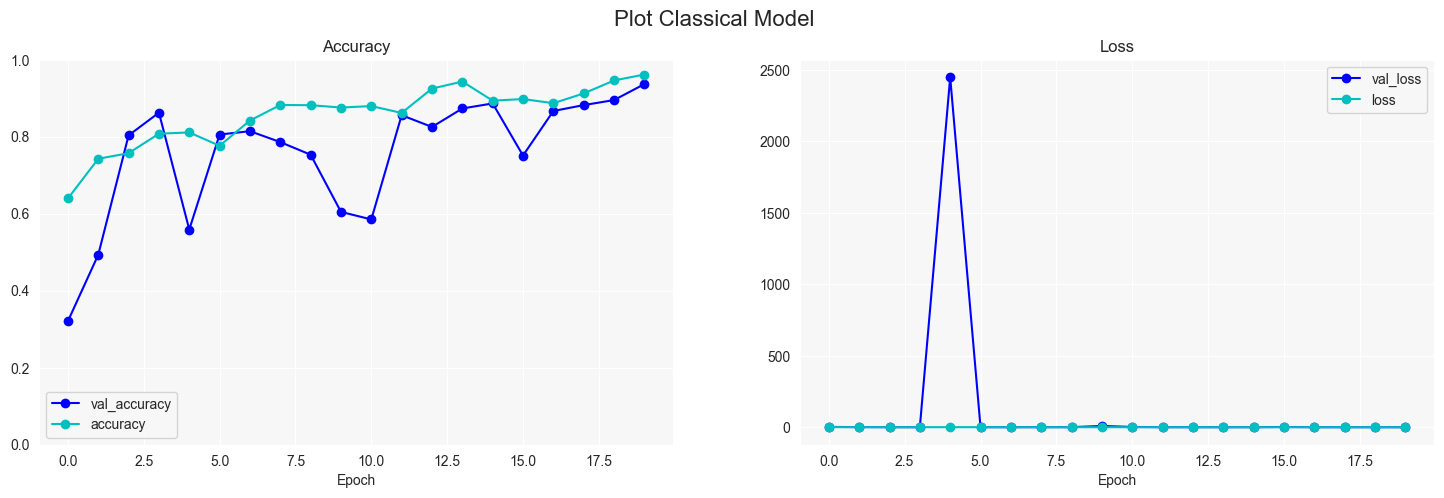

In [31]:
# create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

# plot the validation and training accuracy on the first subplot
ax1.plot(history.history["val_accuracy"], "-ob", label="val_accuracy")
ax1.plot(history.history["accuracy"], "-oc", label="accuracy")
ax1.set_ylim([0, 1])
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.legend()

# plot the validation and training loss on the second subplot
ax2.plot(history.history["val_loss"], "-ob", label="val_loss")
ax2.plot(history.history["loss"], "-oc", label="loss")
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.legend()

# add a super title to the figure
fig.suptitle("Plot Classical Model", fontsize=16)

# save the plot to a file
plt.savefig("Images/classical_model_plot.png")

# display the plot
plt.show()

## Average accuracy & Highest accuracy

In [32]:
# get the highest accuracy
highest_acc = max(history.history["accuracy"])

# get the average accuracy
avg_acc = sum(history.history["accuracy"]) / len(history.history["accuracy"])

# convert the highest accuracy to a percentage
highest_acc_percent = highest_acc * 100

# convert the average accuracy to a percentage
avg_acc_percent = avg_acc * 100

# print the highest accuracy as a percentage
print(f"Highest accuracy: {highest_acc_percent:.2f}%")

# print the average accuracy as a percentage
print(f"Average accuracy: {avg_acc_percent:.2f}%")

Highest accuracy: 96.16%
Average accuracy: 85.63%


## Load the classical model

In [33]:
model = K.models.load_model('InceptionV3.h5')

In [34]:
# predict the classes of the test set
yhat = model.predict(X_test)
yhat = yhat.argmax(axis=1)

# print the classification report
print('\n-----------------------Classification Report-----------------------\n')
print(classification_report(y_test, yhat))

15/15 [==============================] - 5s 245ms/step

-----------------------Classification Report-----------------------

              precision    recall  f1-score   support

         1.0       0.84      0.95      0.89       113
         2.0       0.98      0.92      0.95       213
         3.0       0.95      0.96      0.96       132

    accuracy                           0.94       458
   macro avg       0.93      0.94      0.93       458
weighted avg       0.94      0.94      0.94       458



## Getting the confusion matrix

In [35]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    # Set the background color of the plot
    plt.rcParams['axes.facecolor'] = '#f7f7f7'

    # Create the plot
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)

    # Add a colorbar
    cbar = ax.figure.colorbar(im, ax=ax)

    # Set the font size and color of the tick labels
    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(classes, fontsize=14, color='#333333')
    ax.set_yticklabels(classes, fontsize=14, color='#333333')

    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    # Loop over the data and add text annotations
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=16)

    # Set the title and axis labels
    ax.set_title(title, fontsize=18, color='#333333')
    ax.set_xlabel('Predicted label', fontsize=16, color='#333333')
    ax.set_ylabel('True label', fontsize=16, color='#333333')

    # Set the colorbar label
    cbar.ax.set_ylabel('Count', rotation=-90, va="bottom",
                       fontsize=14, color='#333333')

    # Adjust the layout and show the plot
    fig.tight_layout()

    # Save the plot to a file
    plt.savefig('Images/confusion_matrix_for_Classical_model.png')
    
    # Show the plot
    plt.show()

Confusion matrix, without normalization


<Figure size 600x600 with 0 Axes>

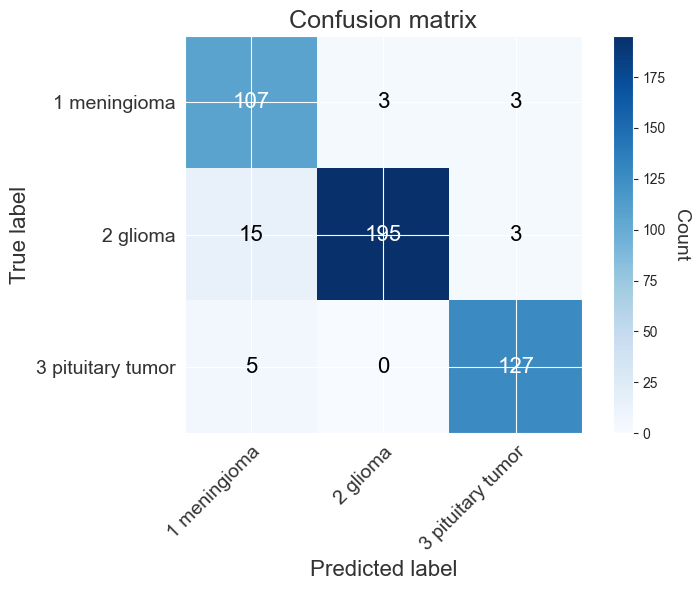

In [36]:
# Compute confusion matrix
cnf_matrix = tf.math.confusion_matrix(y_test, yhat)
np.set_printoptions(precision=2)

# Plot non-normalized confusion matrix
plt.figure(figsize=(6, 6))
plot_confusion_matrix(np.array(cnf_matrix[1:, 1:]), classes=['1 meningioma', '2 glioma', '3 pituitary tumor'], normalize=False,  title='Confusion matrix')

## Versions of the used libraries 

In [37]:
# Define colors for printing
PINK = '\033[95m'
BLUE = '\033[34m'
ENDC = '\033[m'

# Print library versions with color and formatting
print(f"{PINK}Python version:   {ENDC}{sys.version.split()[0]}")
print(f"{BLUE}NumPy version:    {ENDC}{np.__version__}")
print(f"{PINK}Pandas version:   {ENDC}{pd.__version__}")
print(f"{BLUE}Matplotlib version:{ENDC}{mpl.__version__}")
print(f"{PINK}OpenCV version:   {ENDC}{cv2.__version__}")
print(f"{BLUE}Scikit-learn version:{ENDC}{sklearn.__version__}")
print(f"{PINK}TensorFlow version:{ENDC}{tf.__version__}")
print(f"{BLUE}Pennylane version:{ENDC}{qml.__version__}")

Python version:   3.11.5
NumPy version:    1.23.5
Pandas version:   2.1.0
Matplotlib version:3.8.0
OpenCV version:   4.8.0
Scikit-learn version:1.3.1
TensorFlow version:2.13.0
Pennylane version:0.32.0
